# Week 4 Dataset Creation

Instructor notebook. Generates `mackintosh_model_data.csv` by simulating the Mackintosh (1975) associative-learning model (basic conditioning, overshadowing, blocking) across a range of learning rates.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

# Set random seed for reproducibility
np.random.seed(73125)

# Mackintosh Model of Associative Conditioning

### General Conditioning

Generated Mackintosh Model Datasets (Corrected):
Total datasets: 15
Total trials: 475

Dataset types:
Basic conditioning: 5
Overshadowing: 5
Blocking: 5

Data saved to 'mackintosh_model_data_corrected.csv'


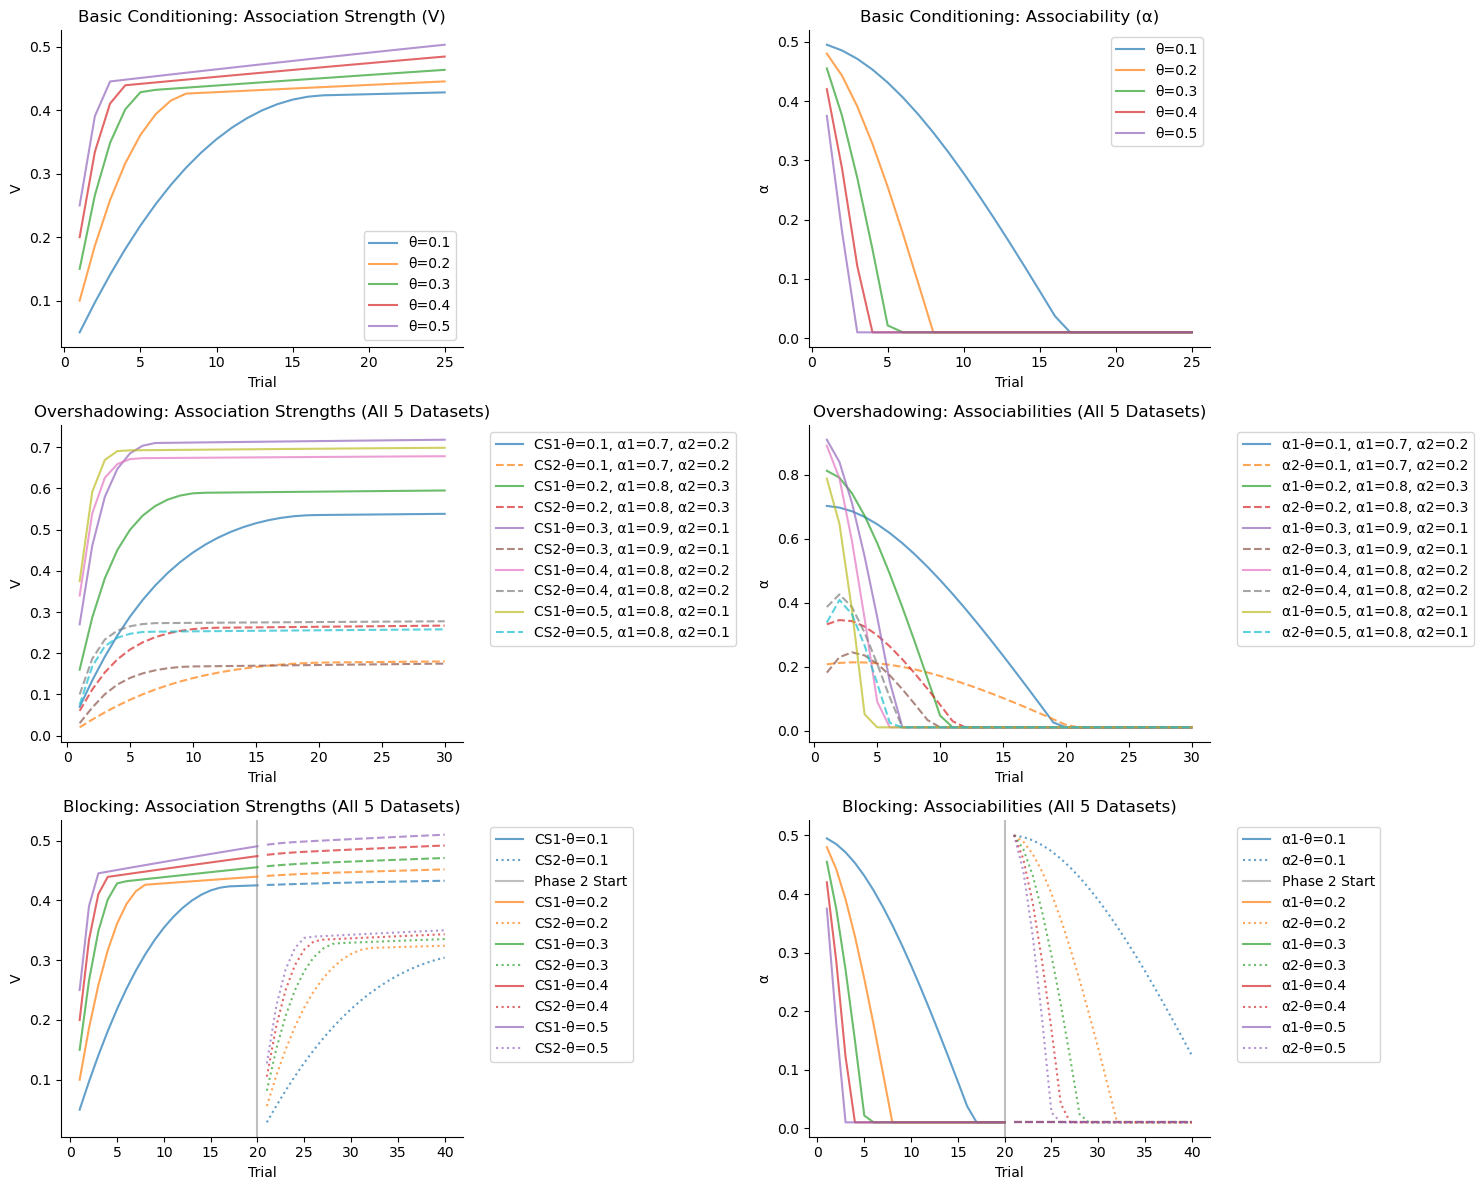


Summary Statistics for All Datasets:

Basic Conditioning - Final V values:
  Dataset 1 (θ=0.1): V=0.428, α=0.010
  Dataset 2 (θ=0.2): V=0.445, α=0.010
  Dataset 3 (θ=0.3): V=0.464, α=0.010
  Dataset 4 (θ=0.4): V=0.485, α=0.010
  Dataset 5 (θ=0.5): V=0.503, α=0.010

Overshadowing - Final values:
  Dataset 1 (θ=0.1): V1=0.538, V2=0.180, V1/V2=2.99
    Initial α1=0.7, α2=0.2
    Final α1=0.010, α2=0.010
  Dataset 2 (θ=0.2): V1=0.595, V2=0.267, V1/V2=2.23
    Initial α1=0.8, α2=0.3
    Final α1=0.010, α2=0.010
  Dataset 3 (θ=0.3): V1=0.718, V2=0.175, V1/V2=4.11
    Initial α1=0.9, α2=0.1
    Final α1=0.010, α2=0.010
  Dataset 4 (θ=0.4): V1=0.678, V2=0.278, V1/V2=2.44
    Initial α1=0.8, α2=0.2
    Final α1=0.010, α2=0.010
  Dataset 5 (θ=0.5): V1=0.699, V2=0.258, V1/V2=2.71
    Initial α1=0.8, α2=0.1
    Final α1=0.010, α2=0.010

Blocking - Final values:
  Dataset 1 (θ=0.1):
    V1 at end of Phase 1: 0.425
    Final V1: 0.433, Final V2: 0.304
    ΔV1: 0.008, V2/ΔV1: 39.820
  Dataset 2 (θ=0

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Set random seed for reproducibility
np.random.seed(73125)

class MackintoshModel:
    def __init__(self, theta=0.3):
        self.theta = theta  # Learning rate parameter
        
    def update_association(self, alpha, lambda_val, V_current):
        """
        Update association strength: ΔVA₁ = αA₁θ(λ - VA₁)
        """
        delta_V = alpha * self.theta * (lambda_val - V_current)
        return delta_V
    
    def update_associability(self, alpha, lambda_val, V_current, V_other=0):
        """
        Update associability based on prediction accuracy
        α(t+1) = α(t) + θ[|λ - V_current| - |λ - V_other|]
        """
        prediction_error_current = abs(lambda_val - V_current)
        prediction_error_other = abs(lambda_val - V_other)
        delta_alpha = self.theta * (prediction_error_current - prediction_error_other)
        return alpha + delta_alpha

def simulate_basic_conditioning(trials=25, alpha_init=0.5, theta=0.3, lambda_val=1.0):
    """Basic conditioning with one CS and one US"""
    model = MackintoshModel(theta)
    
    # Initialize
    alpha = alpha_init
    V = 0.0
    
    data = []
    
    for trial in range(trials):
        # Update association strength
        delta_V = model.update_association(alpha, lambda_val, V)
        V += delta_V
        
        # Update associability
        alpha = model.update_associability(alpha, lambda_val, V)
        
        # Ensure associability stays within bounds
        alpha = np.clip(alpha, 0.01, 1.0)
        
        data.append({
            'trial': trial + 1,
            'alpha': alpha,
            'V': V,
            'delta_V': delta_V,
            'lambda': lambda_val,
            'theta': theta
        })
    
    return pd.DataFrame(data)

def simulate_overshadowing(trials=30, alpha1_init=0.8, alpha2_init=0.3, theta=0.3, lambda_val=1.0):
    """
    Overshadowing: Two CSs presented together, but CS1 has higher initial associability
    CS1 should overshadow CS2 due to higher salience
    """
    model = MackintoshModel(theta)
    
    # Initialize two stimuli with different associabilities
    alpha1 = alpha1_init  # High associability (salient stimulus)
    alpha2 = alpha2_init  # Low associability (less salient stimulus)
    V1 = 0.0
    V2 = 0.0
    
    data = []
    
    for trial in range(trials):
        # Both CSs are present, total associative strength
        V_total = V1 + V2
        
        # Update associations for each CS
        delta_V1 = model.update_association(alpha1, lambda_val, V_total)
        delta_V2 = model.update_association(alpha2, lambda_val, V_total)
        
        V1 += delta_V1
        V2 += delta_V2
        
        # Update associabilities
        alpha1 = model.update_associability(alpha1, lambda_val, V_total, V2)
        alpha2 = model.update_associability(alpha2, lambda_val, V_total, V1)
        
        # Ensure associabilities stay within bounds
        alpha1 = np.clip(alpha1, 0.01, 1.0)
        alpha2 = np.clip(alpha2, 0.01, 1.0)
        
        data.append({
            'trial': trial + 1,
            'alpha1': alpha1,
            'alpha2': alpha2,
            'V1': V1,
            'V2': V2,
            'delta_V1': delta_V1,
            'delta_V2': delta_V2,
            'lambda': lambda_val,
            'theta': theta
        })
    
    return pd.DataFrame(data)

def simulate_blocking(trials=40, alpha_init=0.5, theta=0.3, lambda_val=1.0):
    """
    Blocking: CS1 trained alone first, then CS1+CS2 together
    CS1 should block learning to CS2 because it already predicts the US
    """
    model = MackintoshModel(theta)
    
    # Phase 1: CS1 alone (trials 1-20) - establish strong association
    alpha1 = alpha_init
    alpha2 = alpha_init
    V1 = 0.0
    V2 = 0.0
    
    data = []
    
    for trial in range(trials):
        if trial < 20:  # Phase 1: CS1 alone - establish blocking stimulus
            delta_V1 = model.update_association(alpha1, lambda_val, V1)
            V1 += delta_V1
            
            # Update associability for CS1
            alpha1 = model.update_associability(alpha1, lambda_val, V1)
            alpha1 = np.clip(alpha1, 0.01, 1.0)
            
            data.append({
                'trial': trial + 1,
                'phase': 'Phase1',
                'alpha1': alpha1,
                'alpha2': alpha2,
                'V1': V1,
                'V2': V2,
                'delta_V1': delta_V1,
                'delta_V2': 0,
                'lambda': lambda_val,
                'theta': theta
            })
            
        else:  # Phase 2: CS1 + CS2 together - CS1 should block CS2
            V_total = V1 + V2
            delta_V1 = model.update_association(alpha1, lambda_val, V_total)
            delta_V2 = model.update_association(alpha2, lambda_val, V_total)
            
            V1 += delta_V1
            V2 += delta_V2
            
            # Update associabilities
            alpha1 = model.update_associability(alpha1, lambda_val, V_total, V2)
            alpha2 = model.update_associability(alpha2, lambda_val, V_total, V1)
            
            alpha1 = np.clip(alpha1, 0.01, 1.0)
            alpha2 = np.clip(alpha2, 0.01, 1.0)
            
            data.append({
                'trial': trial + 1,
                'phase': 'Phase2',
                'alpha1': alpha1,
                'alpha2': alpha2,
                'V1': V1,
                'V2': V2,
                'delta_V1': delta_V1,
                'delta_V2': delta_V2,
                'lambda': lambda_val,
                'theta': theta
            })
    
    return pd.DataFrame(data)

# Generate datasets with different learning rates
learning_rates = [0.1, 0.2, 0.3, 0.4, 0.5]

# Basic conditioning datasets
basic_datasets = []
for i, theta in enumerate(learning_rates):
    df = simulate_basic_conditioning(theta=theta)
    df['dataset_id'] = f'Basic_{i+1}'
    basic_datasets.append(df)

# Overshadowing datasets - vary the difference in initial associability
overshadowing_datasets = []
alpha1_values = [0.7, 0.8, 0.9, 0.85, 0.75]  # High associability for CS1
alpha2_values = [0.2, 0.3, 0.1, 0.25, 0.15]  # Low associability for CS2

for i, theta in enumerate(learning_rates):
    df = simulate_overshadowing(theta=theta, alpha1_init=alpha1_values[i], alpha2_init=alpha2_values[i])
    df['dataset_id'] = f'Overshadowing_{i+1}'
    df['alpha1_init'] = alpha1_values[i]
    df['alpha2_init'] = alpha2_values[i]
    overshadowing_datasets.append(df)

# Blocking datasets
blocking_datasets = []
for i, theta in enumerate(learning_rates):
    df = simulate_blocking(theta=theta)
    df['dataset_id'] = f'Blocking_{i+1}'
    blocking_datasets.append(df)

# Combine all datasets
all_data = pd.concat(basic_datasets + overshadowing_datasets + blocking_datasets, 
                     ignore_index=True)

# Display summary
print("Generated Mackintosh Model Datasets (Corrected):")
print(f"Total datasets: {len(all_data['dataset_id'].unique())}")
print(f"Total trials: {len(all_data)}")
print("\nDataset types:")
print(f"Basic conditioning: {len(basic_datasets)}")
print(f"Overshadowing: {len(overshadowing_datasets)}")
print(f"Blocking: {len(blocking_datasets)}")

# Save to CSV
all_data.to_csv('mackintosh_model_data.csv', index=False)
print("\nData saved to 'mackintosh_model_data.csv'")

# Create visualization plots showing ALL datasets
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# Plot basic conditioning - Association strength
for i, df in enumerate(basic_datasets):
    axes[0,0].plot(df['trial'], df['V'], label=f'θ={df["theta"].iloc[0]:.1f}', alpha=0.7)
axes[0,0].set_title('Basic Conditioning: Association Strength (V)')
axes[0,0].set_xlabel('Trial')
axes[0,0].set_ylabel('V')
axes[0,0].legend()

# Plot basic conditioning - Associability
for i, df in enumerate(basic_datasets):
    axes[0,1].plot(df['trial'], df['alpha'], label=f'θ={df["theta"].iloc[0]:.1f}', alpha=0.7)
axes[0,1].set_title('Basic Conditioning: Associability (α)')
axes[0,1].set_xlabel('Trial')
axes[0,1].set_ylabel('α')
axes[0,1].legend()

# Plot ALL overshadowing datasets - Association strengths
for i, df in enumerate(overshadowing_datasets):
    alpha1_init = df['alpha1_init'].iloc[0]
    alpha2_init = df['alpha2_init'].iloc[0]
    theta = df['theta'].iloc[0]
    label = f'θ={theta:.1f}, α1={alpha1_init:.1f}, α2={alpha2_init:.1f}'
    axes[1,0].plot(df['trial'], df['V1'], label=f'CS1-{label}', alpha=0.7, linestyle='-')
    axes[1,0].plot(df['trial'], df['V2'], label=f'CS2-{label}', alpha=0.7, linestyle='--')
axes[1,0].set_title('Overshadowing: Association Strengths (All 5 Datasets)')
axes[1,0].set_xlabel('Trial')
axes[1,0].set_ylabel('V')
axes[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot ALL overshadowing datasets - Associabilities
for i, df in enumerate(overshadowing_datasets):
    alpha1_init = df['alpha1_init'].iloc[0]
    alpha2_init = df['alpha2_init'].iloc[0]
    theta = df['theta'].iloc[0]
    label = f'θ={theta:.1f}, α1={alpha1_init:.1f}, α2={alpha2_init:.1f}'
    axes[1,1].plot(df['trial'], df['alpha1'], label=f'α1-{label}', alpha=0.7, linestyle='-')
    axes[1,1].plot(df['trial'], df['alpha2'], label=f'α2-{label}', alpha=0.7, linestyle='--')
axes[1,1].set_title('Overshadowing: Associabilities (All 5 Datasets)')
axes[1,1].set_xlabel('Trial')
axes[1,1].set_ylabel('α')
axes[1,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot ALL blocking datasets - Association strengths
for i, df in enumerate(blocking_datasets):
    theta = df['theta'].iloc[0]
    phase1 = df[df['phase'] == 'Phase1']
    phase2 = df[df['phase'] == 'Phase2']
    
    # Plot CS1 (solid lines)
    axes[2,0].plot(phase1['trial'], phase1['V1'], alpha=0.7, linestyle='-', 
                   color=f'C{i}', label=f'CS1-θ={theta:.1f}')
    axes[2,0].plot(phase2['trial'], phase2['V1'], alpha=0.7, linestyle='--', 
                   color=f'C{i}')
    
    # Plot CS2 (dotted lines)
    axes[2,0].plot(phase2['trial'], phase2['V2'], alpha=0.7, linestyle=':', 
                   color=f'C{i}', label=f'CS2-θ={theta:.1f}')
    
    # Add phase boundary
    if i == 0:  # Only add once
        axes[2,0].axvline(x=20, color='gray', linestyle='-', alpha=0.5, label='Phase 2 Start')

axes[2,0].set_title('Blocking: Association Strengths (All 5 Datasets)')
axes[2,0].set_xlabel('Trial')
axes[2,0].set_ylabel('V')
axes[2,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot ALL blocking datasets - Associabilities
for i, df in enumerate(blocking_datasets):
    theta = df['theta'].iloc[0]
    phase1 = df[df['phase'] == 'Phase1']
    phase2 = df[df['phase'] == 'Phase2']
    
    # Plot α1 (solid lines)
    axes[2,1].plot(phase1['trial'], phase1['alpha1'], alpha=0.7, linestyle='-', 
                   color=f'C{i}', label=f'α1-θ={theta:.1f}')
    axes[2,1].plot(phase2['trial'], phase2['alpha1'], alpha=0.7, linestyle='--', 
                   color=f'C{i}')
    
    # Plot α2 (dotted lines)
    axes[2,1].plot(phase2['trial'], phase2['alpha2'], alpha=0.7, linestyle=':', 
                   color=f'C{i}', label=f'α2-θ={theta:.1f}')
    
    # Add phase boundary
    if i == 0:  # Only add once
        axes[2,1].axvline(x=20, color='gray', linestyle='-', alpha=0.5, label='Phase 2 Start')

axes[2,1].set_title('Blocking: Associabilities (All 5 Datasets)')
axes[2,1].set_xlabel('Trial')
axes[2,1].set_ylabel('α')
axes[2,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
sns.despine(top=True,right=True)
plt.show()

# Print summary statistics for all datasets
print("\nSummary Statistics for All Datasets:")

print("\nBasic Conditioning - Final V values:")
for i, df in enumerate(basic_datasets):
    theta = df['theta'].iloc[0]
    final_V = df['V'].iloc[-1]
    final_alpha = df['alpha'].iloc[-1]
    print(f"  Dataset {i+1} (θ={theta:.1f}): V={final_V:.3f}, α={final_alpha:.3f}")

print("\nOvershadowing - Final values:")
for i, df in enumerate(overshadowing_datasets):
    theta = df['theta'].iloc[0]
    alpha1_init = df['alpha1_init'].iloc[0]
    alpha2_init = df['alpha2_init'].iloc[0]
    final_V1 = df['V1'].iloc[-1]
    final_V2 = df['V2'].iloc[-1]
    final_alpha1 = df['alpha1'].iloc[-1]
    final_alpha2 = df['alpha2'].iloc[-1]
    overshadowing_ratio = final_V1 / final_V2 if final_V2 > 0 else float('inf')
    print(f"  Dataset {i+1} (θ={theta:.1f}): V1={final_V1:.3f}, V2={final_V2:.3f}, V1/V2={overshadowing_ratio:.2f}")
    print(f"    Initial α1={alpha1_init:.1f}, α2={alpha2_init:.1f}")
    print(f"    Final α1={final_alpha1:.3f}, α2={final_alpha2:.3f}")

print("\nBlocking - Final values:")
for i, df in enumerate(blocking_datasets):
    theta = df['theta'].iloc[0]
    v1_phase1 = df[df['trial'] == 20]['V1'].iloc[0]
    final_V1 = df['V1'].iloc[-1]
    final_V2 = df['V2'].iloc[-1]
    delta_V1 = final_V1 - v1_phase1
    blocking_ratio = final_V2 / delta_V1 if delta_V1 > 0 else 0
    print(f"  Dataset {i+1} (θ={theta:.1f}):")
    print(f"    V1 at end of Phase 1: {v1_phase1:.3f}")
    print(f"    Final V1: {final_V1:.3f}, Final V2: {final_V2:.3f}")
    print(f"    ΔV1: {delta_V1:.3f}, V2/ΔV1: {blocking_ratio:.3f}")